In [3]:
import seaborn as sns

In [4]:
sns.get_dataset_names()

['anagrams',
 'anscombe',
 'attention',
 'brain_networks',
 'car_crashes',
 'diamonds',
 'dots',
 'dowjones',
 'exercise',
 'flights',
 'fmri',
 'geyser',
 'glue',
 'healthexp',
 'iris',
 'mpg',
 'penguins',
 'planets',
 'seaice',
 'taxis',
 'tips',
 'titanic']

In [5]:
df = sns.load_dataset("tips")

# scatter

상관관계 시각화 - 분포, 경향성, 이상치 탐색
- 회귀분석, 군집분석 등에서 탐색적데이터분석에 활용

<Axes: xlabel='total_bill', ylabel='tip'>

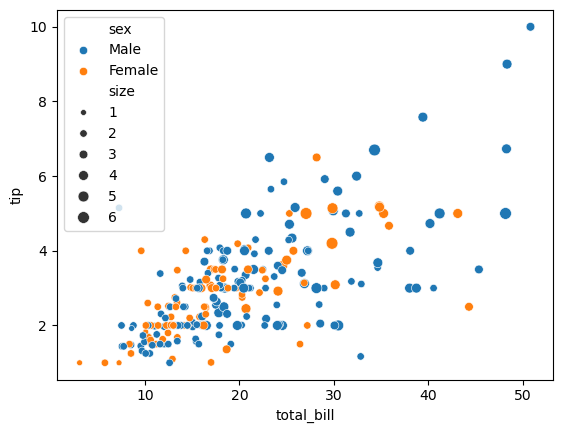

In [6]:
sns.scatterplot(
    x=df['total_bill'], 
    y=df['tip'], 
    hue=df['sex'], 
    size=df['size']
)


In [66]:
# 데이터셋 global_internet_users.csv - 인터넷 사용자 데이터
import pandas as pd
df = pd.read_csv('./data/global_internet_users.csv')
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8867 entries, 0 to 8866
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              8867 non-null   int64  
 1   Entity                  8867 non-null   object 
 2   Code                    8867 non-null   object 
 3   Year                    8867 non-null   int64  
 4   Cellular Subscription   8867 non-null   float64
 5   Internet Users(%)       8867 non-null   float64
 6   No. of Internet Users   8867 non-null   int64  
 7   Broadband Subscription  8867 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 554.3+ KB


- 주피터 노트북 → plt.show() 없어도 됨

- Python 스크립트 실행 → plt.show() 필수

- Matplotlib 기능 활용 시 → plt 필요

<Axes: xlabel='Year', ylabel='No. of Internet Users'>

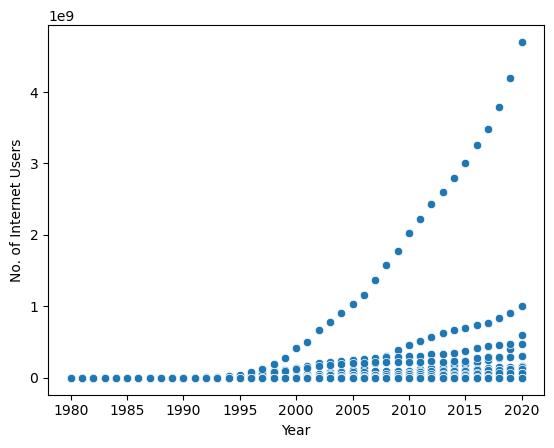

In [12]:
# 산점도 그리기
sns.scatterplot(x='Year', y='No. of Internet Users', data=df)

In [ ]:
# 연도별 사용자 - 국가/지역 별로 구분해서 시각화 - hue size

In [ ]:
df.Entity.unique() ## 국가

In [16]:
entities = ['China','India','Finland']
df_country = df.loc[df['Entity'].isin(entities)]
df_country[:5]

,Unnamed: 0,Entity,Code,Year,Cellular Subscription,Internet Users(%),No. of Internet Users,Broadband Subscription
1579,1579,China,CHN,1980,0.0,0.0,0,0.0
1580,1580,China,CHN,1981,0.0,0.0,0,0.0
1581,1581,China,CHN,1982,0.0,0.0,0,0.0
1582,1582,China,CHN,1983,0.0,0.0,0,0.0
1583,1583,China,CHN,1984,0.0,0.0,0,0.0


<Axes: xlabel='Year', ylabel='No. of Internet Users'>

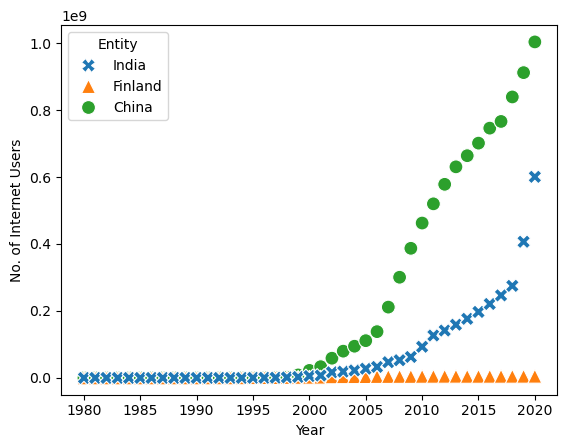

In [31]:
sns.scatterplot(
    x=df['Year'], 
    y=df['No. of Internet Users'], 
    data = df_country,
    hue='Entity',
    hue_order=['India','Finland','China'],
    markers=['o','^','X'],s=100,
    style='Entity'
   
) 

# Plotly


- go.Figure()
- add_trace()
- update_layout()
- show()
- write_image()


In [36]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8867 entries, 0 to 8866
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Unnamed: 0              8867 non-null   int64  
 1   Entity                  8867 non-null   object 
 2   Code                    8867 non-null   object 
 3   Year                    8867 non-null   int64  
 4   Cellular Subscription   8867 non-null   float64
 5   Internet Users(%)       8867 non-null   float64
 6   No. of Internet Users   8867 non-null   int64  
 7   Broadband Subscription  8867 non-null   float64
dtypes: float64(3), int64(3), object(2)
memory usage: 554.3+ KB


In [45]:
import plotly.express as px
fig = px.scatter(data_frame=df, 
                 x="Year", 
                 y="No. of Internet Users",
                 width= 600,
                 height= 600
)
fig.show()


In [47]:
color = px.colors.qualitative.Light24
px.scatter(data_frame=df_country,
           x='Year',
           y='No. of Internet Users',
           width=400,
           height=400,
           color='Entity',
           color_discrete_sequence=color,
           symbol='Entity',
           size='No. of Internet Users'
           )

산점도는 데이터의 양에 따라 효과가 달라진다.</br>
size 그룹간 차이 식별이 어려워질 수 있다.</br>
최대2개 정도만 구분 - hue,  style

# regplot
- Seaborn에서 산점도와 회귀선을 함께 그려주는 함수

In [51]:
tip_df = sns.load_dataset("tips")
tip_df.head()

,total_bill,tip,sex,smoker,day,time,size
0,16.99,1.01,Female,No,Sun,Dinner,2
1,10.34,1.66,Male,No,Sun,Dinner,3
2,21.01,3.50,Male,No,Sun,Dinner,3
3,23.68,3.31,Male,No,Sun,Dinner,2
4,24.59,3.61,Female,No,Sun,Dinner,4


오차구간을 함께 볼 수 있다. ci 속성

<Axes: xlabel='total_bill', ylabel='tip'>

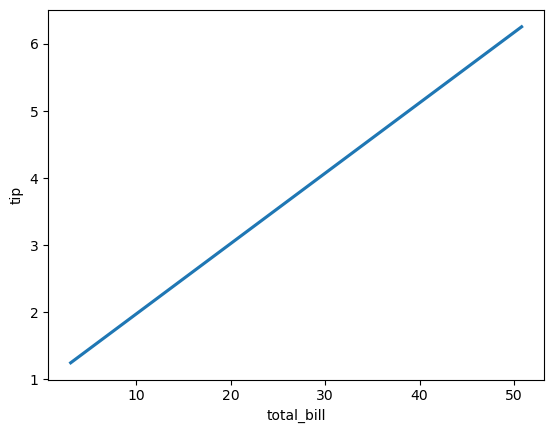

In [58]:
sns.regplot(x=tip_df['total_bill'],y=tip_df['tip'], scatter = False,ci=None)

회귀선: 데이터 포인트들의 전반적인 경향(trend)을 직선 형태로 나타낸 것

In [ ]:
# size, tip 으로 regplot 그리기

In [ ]:
# plotly에서 regplot
px.scatter(
    data_frame= tip_df,
    x= 'total_bill',
    y='tip',
    width=400,
    height=400,
    trendline= 'ols', # regplot 동일한역할 -Plotly px.scatter + trendline='ols'` → 인터랙티브 산점도 + 선형 회귀선
    color= 'smoker'
)


# lineplot
- 졈들을 이어주는 형식으로 데이터의 추세를 확인하는 함수

C:\Users\Admin\AppData\Local\Temp\ipykernel_1228\2785770464.py:2: FutureWarning:



The `ci` parameter is deprecated. Use `errorbar=('ci', 100)` for the same effect.




<Axes: xlabel='size', ylabel='tip'>

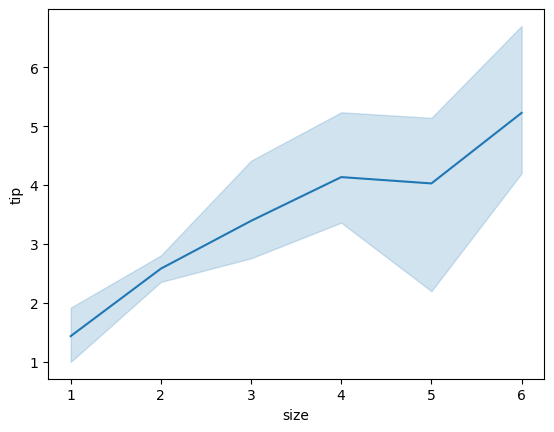

In [65]:
# ci기본값 95
sns.lineplot(x='size', y='tip', data =tip_df, ci=100)

In [67]:
entities = ['China','India','Finland']
df_country = df.loc[df['Entity'].isin(entities)]
df_country[:5]

,Unnamed: 0,Entity,Code,Year,Cellular Subscription,Internet Users(%),No. of Internet Users,Broadband Subscription
1579,1579,China,CHN,1980,0.0,0.0,0,0.0
1580,1580,China,CHN,1981,0.0,0.0,0,0.0
1581,1581,China,CHN,1982,0.0,0.0,0,0.0
1582,1582,China,CHN,1983,0.0,0.0,0,0.0
1583,1583,China,CHN,1984,0.0,0.0,0,0.0


<Axes: xlabel='Year', ylabel='No. of Internet Users'>

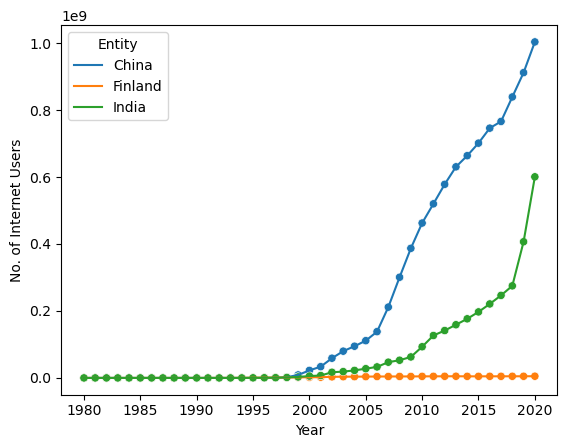

In [72]:
sns.lineplot(x='Year',
             y='No. of Internet Users',
             data =df_country,
             hue = 'Entity'
             )

sns.scatterplot(x='Year',
             y='No. of Internet Users',
             data =df_country,
             hue = 'Entity',
             legend=False
             )

In [ ]:
# scatter +line > 추세 + 데이터 양을 함께 확인할 수 있다.

In [78]:
px.line(
    data_frame=df_country,
    x='Year',
    y='No. of Internet Users',
    width=400,
    height=400,
    line_dash='Entity',
    color='Entity',
    symbol='Entity'
)

# boxplot
- 이상치 탐지
- 통계량 확인
- 분포 확인

In [82]:
ev_df = pd.read_csv('./data/EV_charge.csv')
ev_df.head()

,sessionId,kwhTotal,dollars,created,ended,startTime,endTime,chargeTimeHrs,weekday,platform,...,managerVehicle,facilityType,Mon,Tues,Wed,Thurs,Fri,Sat,Sun,reportedZip
0,1366563,7.78,0.00,0014-11-18 15:40:26,0014-11-18 17:11:04,15,17,1.510556,Tue,android,...,0,3,0,1,0,0,0,0,0,0
1,3075723,9.74,0.00,0014-11-19 17:40:26,0014-11-19 19:51:04,17,19,2.177222,Wed,android,...,0,3,0,0,1,0,0,0,0,0
2,4228788,6.76,0.58,0014-11-21 12:05:46,0014-11-21 16:46:04,12,16,4.671667,Fri,android,...,0,3,0,0,0,0,1,0,0,0
3,3173284,6.17,0.00,0014-12-03 19:16:12,0014-12-03 21:02:18,19,21,1.768333,Wed,android,...,0,3,0,0,1,0,0,0,0,0
4,3266500,0.93,0.00,0014-12-11 20:56:11,0014-12-11 21:14:06,20,21,0.298611,Thu,android,...,0,3,0,0,0,1,0,0,0,0


In [83]:
ev_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3395 entries, 0 to 3394
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sessionId       3395 non-null   int64  
 1   kwhTotal        3395 non-null   float64
 2   dollars         3395 non-null   float64
 3   created         3395 non-null   object 
 4   ended           3395 non-null   object 
 5   startTime       3395 non-null   int64  
 6   endTime         3395 non-null   int64  
 7   chargeTimeHrs   3395 non-null   float64
 8   weekday         3395 non-null   object 
 9   platform        3395 non-null   object 
 10  distance        2330 non-null   float64
 11  userId          3395 non-null   int64  
 12  stationId       3395 non-null   int64  
 13  locationId      3395 non-null   int64  
 14  managerVehicle  3395 non-null   int64  
 15  facilityType    3395 non-null   int64  
 16  Mon             3395 non-null   int64  
 17  Tues            3395 non-null   i

<Axes: xlabel='weekday', ylabel='kwhTotal'>

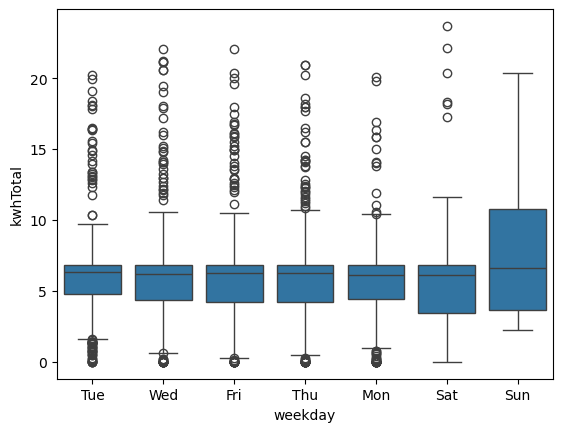

In [88]:
sns.boxplot(
    x='weekday',        # 요일
    y='kwhTotal',       # 충전량
    data=ev_df
)


In [ ]:
# 원본데이터 + 통계량을 같이 표현한다. > boxplot +stripplot

c:\Users\Admin\miniconda3\envs\streamlit_env\lib\site-packages\seaborn\categorical.py:3399: UserWarning:

74.8% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

c:\Users\Admin\miniconda3\envs\streamlit_env\lib\site-packages\seaborn\categorical.py:3399: UserWarning:

77.3% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

c:\Users\Admin\miniconda3\envs\streamlit_env\lib\site-packages\seaborn\categorical.py:3399: UserWarning:

73.4% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

c:\Users\Admin\miniconda3\envs\streamlit_env\lib\site-packages\seaborn\categorical.py:3399: UserWarning:

78.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

c:\Users\Admin\miniconda3\envs\streamlit_env\lib\site-packages\seaborn\categorical.py:3399: UserWarning:

76.1% of the points cannot be placed; you may 

<Axes: xlabel='weekday', ylabel='kwhTotal'>

c:\Users\Admin\miniconda3\envs\streamlit_env\lib\site-packages\seaborn\categorical.py:3399: UserWarning:

73.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

c:\Users\Admin\miniconda3\envs\streamlit_env\lib\site-packages\seaborn\categorical.py:3399: UserWarning:

76.0% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

c:\Users\Admin\miniconda3\envs\streamlit_env\lib\site-packages\seaborn\categorical.py:3399: UserWarning:

72.6% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

c:\Users\Admin\miniconda3\envs\streamlit_env\lib\site-packages\seaborn\categorical.py:3399: UserWarning:

76.5% of the points cannot be placed; you may want to decrease the size of the markers or use stripplot.

c:\Users\Admin\miniconda3\envs\streamlit_env\lib\site-packages\seaborn\categorical.py:3399: UserWarning:

75.3% of the points cannot be placed; you may 

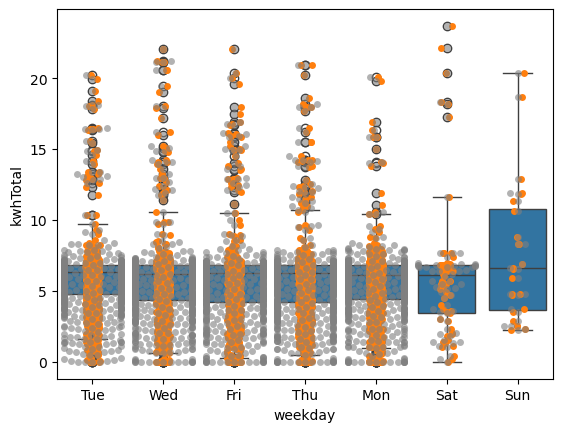

In [92]:
sns.boxplot(
    x='weekday',        # 요일
    y='kwhTotal',       # 충전량
    data=ev_df
)
sns.stripplot(
    x='weekday',        # 요일
    y='kwhTotal',       # 충전량
    data=ev_df
)

sns.swarmplot(
    x='weekday',        # 요일
    y='kwhTotal',       # 충전량
    data=ev_df,
    color= 'gray',
    alpha=0.6
    )

In [ ]:
# boxplot이 만능이 아니다.
# swarmplot: 값이 겹치지 않는다. -> 분포를 잘보여준다. 성능 저하 고려

<Axes: xlabel='weekday', ylabel='kwhTotal'>

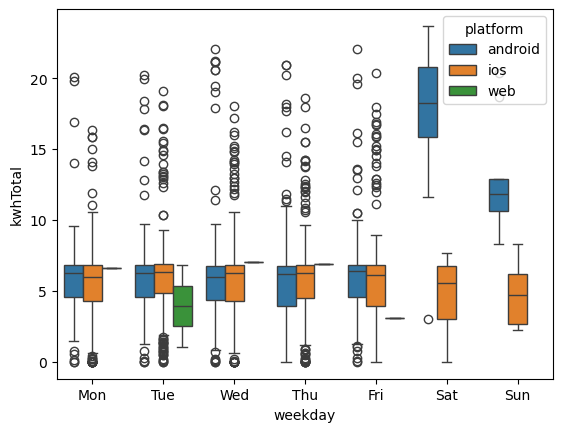

In [96]:
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
sns.boxplot(
    x='weekday',
    y='kwhTotal',
    data=ev_df,
    hue= 'platform',
    order=weekday_order
)

In [108]:
# plotly boxplot
weekday_order = ['Mon', 'Tue', 'Wed', 'Thu', 'Fri', 'Sat', 'Sun']
weekday_orders = {'weekday': weekday_order}
px.box(
    data_frame=ev_df,
    x='weekday',
    y='kwhTotal',
    width=500,
    height=500,
    points ='all',
    category_orders=weekday_orders,
    color='platform'
).show()